# 05 — XGBoost Training

Smart training notebook — avoids full retraining every time.

**How it works:**
- If **no model exists** → trains from scratch (~15 min)
- If **model exists + small update** (< 10% new rows) → continues training on new rows only (~2 min)
- If **model exists + large update** (≥ 10% new rows) → full retrain on all data
- If **dataset unchanged** → skips training, loads existing model

**Run order:** Cell 1 → Cell 2 → Cell 3 → Cell 4 → Cell 5

---
**To force a full retrain** (e.g. after major data update): set `FORCE_RETRAIN = True` in Cell 1

## Cell 1 — Mount Drive + set paths + config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import os
import json

BASE       = '/content/drive/MyDrive/CVE_Project'
PROCESSED  = f'{BASE}/processed'
EMBEDDINGS = f'{BASE}/embeddings'
MODELS     = f'{BASE}/models'
os.makedirs(MODELS, exist_ok=True)

# ── CONFIG ────────────────────────────────────────────────────────────
FORCE_RETRAIN   = False   # Set True to force full retrain regardless
UPDATE_THRESHOLD = 0.10   # If new rows > 10% of old model size → full retrain
TRACKER_FILE     = f'{MODELS}/training_tracker.json'

# ── Load data ─────────────────────────────────────────────────────────
df       = pd.read_csv(f'{PROCESSED}/cves_processed.csv')
bert_emb = np.load(f'{EMBEDDINGS}/bert_embeddings.npy')

print(f'CSV shape:        {df.shape}')
print(f'Embeddings shape: {bert_emb.shape}')
print(f'Rows match:       {len(df) == len(bert_emb)}')

# ── Check training tracker ────────────────────────────────────────────
model_exists = os.path.exists(f'{MODELS}/model_xgb.pkl')
current_rows = len(df)

if model_exists and os.path.exists(TRACKER_FILE):
    with open(TRACKER_FILE, 'r') as f:
        tracker = json.load(f)
    last_trained_rows = tracker.get('trained_on_rows', 0)
    new_rows          = current_rows - last_trained_rows
    pct_new           = new_rows / last_trained_rows if last_trained_rows > 0 else 1.0

    print(f'\nModel found. Last trained on: {last_trained_rows:,} rows')
    print(f'Current dataset:              {current_rows:,} rows')
    print(f'New rows since last train:    {new_rows:,} ({pct_new*100:.1f}%)')

    if FORCE_RETRAIN:
        TRAIN_MODE = 'full'
        print('\nMode: FULL RETRAIN (forced by FORCE_RETRAIN=True)')
    elif new_rows == 0:
        TRAIN_MODE = 'skip'
        print('\nMode: SKIP — dataset unchanged, will load existing model')
    elif pct_new >= UPDATE_THRESHOLD:
        TRAIN_MODE = 'full'
        print(f'\nMode: FULL RETRAIN (new rows {pct_new*100:.1f}% >= threshold {UPDATE_THRESHOLD*100:.0f}%)')
    else:
        TRAIN_MODE = 'update'
        print(f'\nMode: UPDATE — continuing training on {new_rows:,} new rows only')
else:
    TRAIN_MODE        = 'full'
    last_trained_rows = 0
    new_rows          = current_rows
    print('\nMode: FULL RETRAIN (no existing model found)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV shape:        (200431, 24)
Embeddings shape: (200431, 768)
Rows match:       True

Mode: FULL RETRAIN (no existing model found)


## Cell 2 — Build feature matrix

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nlp_cols  = ['entity_count','has_remote','has_unauth','has_exec',
             'has_priv_esc','has_dos','has_overflow','desc_word_count']
meta_cols = ['attack_vector_enc','attack_complexity_enc',
             'privileges_required_enc','user_interaction_enc','scope_enc']

nlp_feats  = df[nlp_cols].values.astype(float)
meta_feats = df[meta_cols].values.astype(float)
X          = np.concatenate([bert_emb, nlp_feats, meta_feats], axis=1)
y          = df['cvss_label'].values

print(f'Fused feature shape: {X.shape}  (768 BERT + 8 NLP + 5 meta = 781)')

le    = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'Classes:             {le.classes_}')

if TRAIN_MODE == 'update':
    # Only use NEW rows for the update training
    X_new  = X[last_trained_rows:]
    y_new  = y_enc[last_trained_rows:]
    X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(
        X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
    )
    print(f'Update train rows:   {len(X_train_up):,}')
    print(f'Update test rows:    {len(X_test_up):,}')

# Always build full test split for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'\nFull train size:     {X_train.shape}')
print(f'Full test size:      {X_test.shape}')

Fused feature shape: (200431, 781)  (768 BERT + 8 NLP + 5 meta = 781)
Classes:             ['Critical' 'High' 'Low' 'Medium']

Full train size:     (160344, 781)
Full test size:      (40087, 781)


## Cell 3 — Train / update / load model

- **skip** → loads saved model, no training
- **update** → loads saved model, continues training on new rows only using XGBoost warm-start
- **full** → trains from scratch on all rows

In [3]:
!pip install xgboost joblib -q

import joblib
import time
from xgboost import XGBClassifier

if TRAIN_MODE == 'skip':
    # ── SKIP: just load existing model ────────────────────────────────
    print('Loading existing model...')
    model_xgb = joblib.load(f'{MODELS}/model_xgb.pkl')
    le        = joblib.load(f'{MODELS}/label_encoder.pkl')
    print('Model loaded. Skipping training.')

elif TRAIN_MODE == 'update':
    # ── UPDATE: continue training on new rows only ────────────────────
    print(f'Loading existing model to continue training...')
    model_xgb = joblib.load(f'{MODELS}/model_xgb.pkl')
    le        = joblib.load(f'{MODELS}/label_encoder.pkl')

    print(f'Continuing training on {len(X_train_up):,} new rows...')
    start = time.time()

    # XGBoost warm-start: set_params + fit with xgb_model
    model_xgb.set_params(n_estimators = model_xgb.n_estimators + 100)
    model_xgb.fit(
        X_train_up, y_train_up,
        eval_set        = [(X_test_up, y_test_up)],
        verbose         = 20,
        xgb_model       = model_xgb.get_booster()
    )
    elapsed = round(time.time() - start, 1)
    print(f'Update training complete in {elapsed}s')

else:
    # ── FULL: train from scratch ──────────────────────────────────────
    print(f'Training XGBoost on {len(X_train):,} rows...')
    start = time.time()

    model_xgb = XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        eval_metric       = 'mlogloss',
        random_state      = 42,
        n_jobs            = -1
    )
    model_xgb.fit(
        X_train, y_train,
        eval_set  = [(X_test, y_test)],
        verbose   = 50
    )
    elapsed = round(time.time() - start, 1)
    print(f'\nTraining complete in {elapsed}s')

Training XGBoost on 160,344 rows...
[0]	validation_0-mlogloss:1.07524
[50]	validation_0-mlogloss:0.70750
[100]	validation_0-mlogloss:0.63169
[150]	validation_0-mlogloss:0.59740
[200]	validation_0-mlogloss:0.57667
[250]	validation_0-mlogloss:0.56269
[299]	validation_0-mlogloss:0.55252

Training complete in 1330.3s


## Cell 4 — Evaluate + SHAP + save

Classification Report:
              precision    recall  f1-score   support

    Critical       0.72      0.74      0.73      4705
        High       0.76      0.72      0.74     14792
         Low       0.88      0.38      0.53      1589
      Medium       0.79      0.86      0.82     19001

    accuracy                           0.77     40087
   macro avg       0.79      0.67      0.70     40087
weighted avg       0.77      0.77      0.77     40087



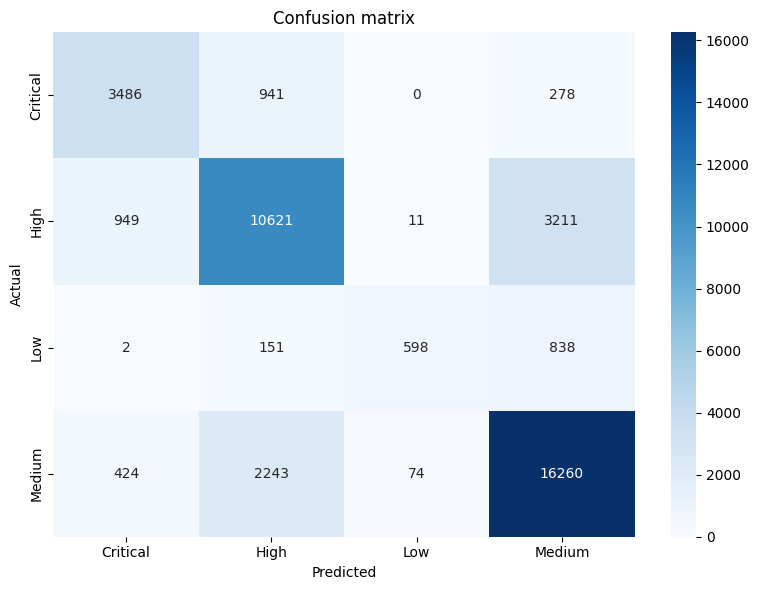

Confusion matrix saved.

Computing SHAP values (on 1000 test samples)...


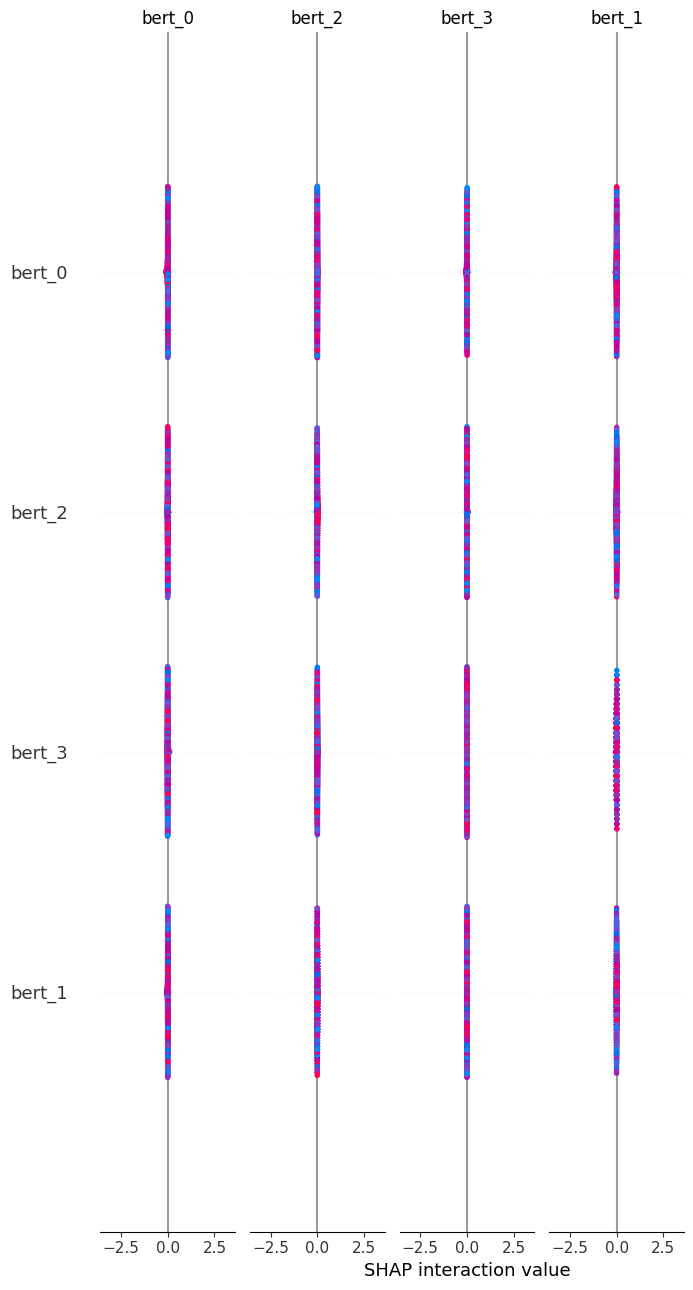

SHAP plot saved.

Model saved to /content/drive/MyDrive/CVE_Project/models/
Tracker updated: trained_on_rows = 200,431


In [8]:
!pip install shap -q

import shap
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Evaluate on full test set ──────────────────────────────────────────
preds = model_xgb.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, preds, target_names=le.classes_))

# ── Confusion matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{MODELS}/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

# ── SHAP (only if model was trained/updated, skip if just loaded) ─────
if TRAIN_MODE != 'skip':
    print('\nComputing SHAP values (on 1000 test samples)...')
    explainer   = shap.TreeExplainer(model_xgb)
    shap_values = explainer.shap_values(X_test[:1000])
    feature_names = (
        [f'bert_{i}' for i in range(768)] + nlp_cols + meta_cols
    )
    shap.summary_plot(
        shap_values, X_test[:1000],
        feature_names = feature_names,
        max_display   = 15,
        show          = False
    )
    plt.tight_layout()
    plt.savefig(f'{MODELS}/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP plot saved.')
else:
    print('\nSHAP skipped (model unchanged).')

# ── Save model + label encoder ────────────────────────────────────────
if TRAIN_MODE != 'skip':
    joblib.dump(model_xgb, f'{MODELS}/model_xgb.pkl')
    joblib.dump(le,        f'{MODELS}/label_encoder.pkl')
    print(f'\nModel saved to {MODELS}/')

    # Update tracker
    with open(TRACKER_FILE, 'w') as f:
        json.dump({'trained_on_rows': current_rows,
                   'train_mode':      TRAIN_MODE}, f)
    print(f'Tracker updated: trained_on_rows = {current_rows:,}')
else:
    print('\nModel unchanged — not re-saved.')

## Cell 5 — Final verification

In [9]:
import joblib
import json
import os

model_loaded = joblib.load(f'{MODELS}/model_xgb.pkl')
le_loaded    = joblib.load(f'{MODELS}/label_encoder.pkl')

print(f'Model type:        {type(model_loaded).__name__}')
print(f'Classes:           {le_loaded.classes_}')
print(f'N estimators:      {model_loaded.n_estimators}')
print(f'Feature count:     {model_loaded.n_features_in_}')

if os.path.exists(TRACKER_FILE):
    with open(TRACKER_FILE) as f:
        tracker = json.load(f)
    print(f'\nTracker info:')
    print(f'  Trained on rows: {tracker["trained_on_rows"]:,}')
    print(f'  Train mode used: {tracker["train_mode"]}')

print(f'\nFiles in {MODELS}:')
for fname in sorted(os.listdir(MODELS)):
    size = os.path.getsize(f'{MODELS}/{fname}')
    print(f'  {fname}  ({size/1024:.1f} KB)')

print('\nAll checks passed. Ready to use in Streamlit app.')

Model type:        XGBClassifier
Classes:           ['Critical' 'High' 'Low' 'Medium']
N estimators:      300
Feature count:     781

Tracker info:
  Trained on rows: 200,431
  Train mode used: full

Files in /content/drive/MyDrive/CVE_Project/models:
  confusion_matrix.png  (57.3 KB)
  label_encoder.pkl  (0.5 KB)
  model_xgb.pkl  (5320.9 KB)
  shap_summary.png  (134.1 KB)
  training_tracker.json  (0.0 KB)

All checks passed. Ready to use in Streamlit app.
